In [33]:
import pandas as pd
from itertools import product
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
def stats(d):
    ret = d["ret"].dropna()
    pos = d["pos"].reindex(ret.index).fillna(0)

    eq = np.exp(ret.cumsum())
    dd = eq / eq.cummax() - 1
    maxdd = dd.min()

    gains = ret[ret > 0]
    losses = ret[ret < 0]
    active = ret[pos != 0]

    return pd.Series({
        "avg_pnl": ret.mean(),
        "SR": ret.mean() / ret.std() * np.sqrt(252),
        "MaxDD": maxdd,
        "Sortino": ret.mean() / losses.std() * np.sqrt(252),
        "VaR_5": ret.quantile(.05),
        "Calmar": ret.mean() * 252 / abs(maxdd),
        "HitRate": (active > 0).mean(),
        "ProfitFactor": gains.sum() / abs(losses.sum()),
        "Exposure": (pos != 0).mean(),
        "Turnover": pos.diff().abs().mean(),
        "WinLoss": gains.mean() / abs(losses.mean())
    })


rows = []

models = {"ridge", "xgb_regression", "logreg", "xgb_sign"}
horizons = {"3", "5", "10", "30", "60"}

for f in Path(".").glob("*_pnl.parquet"):

    name = f.stem.lower().replace("_pnl", "")
    parts = name.split("_")

    if parts[-1] not in horizons:
        continue

    asset = parts[0]
    h = int(parts[-1])
    model = "_".join(parts[1:-1])

    if model not in models:
        continue

    d = pd.read_parquet(f)

    s = stats(d)
    s["asset"] = asset
    s["h"] = h
    s["model"] = model

    rows.append(s)

res = pd.DataFrame(rows)

cols = [
    "avg_pnl", "SR", "MaxDD", "Sortino", "VaR_5",
    "Calmar", "HitRate", "ProfitFactor", "Exposure",
    "Turnover", "WinLoss"
]

for asset in sorted(res.asset.unique()):
    for h in sorted(res.h.unique()):
        tab = (
            res[(res.asset == asset) & (res.h == h)]
            .set_index("model")
            [cols]
            .sort_values("SR", ascending=False)
        )

        print(f"\n{asset.upper()} | h={h}")
        display(tab)


APPLE | h=3


,avg_pnl,SR,MaxDD,Sortino,VaR_5,Calmar,HitRate,ProfitFactor,Exposure,Turnover,WinLoss
model,,,,,,,,,,,
xgb_sign,0.001506,1.052207,-0.444460,1.284646,-0.032740,0.853721,0.512744,1.247839,1.000000,0.210210,0.959596
logreg,0.000553,0.391492,-0.505266,0.473802,-0.037799,0.275982,0.491754,1.077276,1.000000,0.018018,0.913057
xgb_regression,-0.000468,-0.473488,-0.525394,-0.420993,-0.022364,-0.224560,0.372671,0.885722,0.724138,0.306306,0.929140
ridge,-0.002486,-2.080454,-0.833688,-2.041116,-0.035580,-0.751516,0.372014,0.633972,0.878561,0.192192,0.713218



APPLE | h=5


,avg_pnl,SR,MaxDD,Sortino,VaR_5,Calmar,HitRate,ProfitFactor,Exposure,Turnover,WinLoss
model,,,,,,,,,,,
xgb_regression,0.001088,1.067806,-0.278575,1.257678,-0.024169,0.984447,0.462783,1.252237,0.937785,0.164134,1.073346
xgb_sign,0.000944,0.895549,-0.278575,1.094667,-0.024482,0.854308,0.470410,1.200980,1.000000,0.145897,1.057637
logreg,0.000691,0.614205,-0.373027,0.739814,-0.029182,0.466829,0.479514,1.127391,1.000000,0.054711,0.952574
ridge,-0.000571,-0.596009,-0.396769,-0.624385,-0.027249,-0.362484,0.440063,0.882973,0.962064,0.209726,0.806591



APPLE | h=10


...

,avg_pnl,SR,MaxDD,Sortino,VaR_5,Calmar,HitRate,ProfitFactor,Exposure,Turnover,WinLoss
model,,,,,,,,,,,
logreg,0.001448,0.600398,-0.575636,0.874922,-0.056416,0.633739,0.463224,1.120309,1.000000,0.068966,1.044612
xgb_regression,0.000595,0.314581,-0.391028,0.389914,-0.049135,0.383697,0.494692,1.065926,0.737089,0.200627,1.011062
ridge,-0.000001,-0.000680,-0.628451,-0.000809,-0.053910,-0.000566,0.458733,0.999859,0.815336,0.105016,0.969445
xgb_sign,-0.000020,-0.009912,-0.417974,-0.013402,-0.046903,-0.011860,0.410016,0.997965,1.000000,0.250784,1.108426



TESLA | h=30


,avg_pnl,SR,MaxDD,Sortino,VaR_5,Calmar,HitRate,ProfitFactor,Exposure,Turnover,WinLoss
model,,,,,,,,,,,
logreg,0.000693,0.343329,-0.549794,0.460658,-0.049740,0.317720,0.463327,1.067277,1.000000,0.071685,1.054915
xgb_sign,0.000328,0.201880,-0.371578,0.230934,-0.032000,0.222780,0.445438,1.047648,1.000000,0.344086,1.060270
ridge,-0.000076,-0.043001,-0.666016,-0.042808,-0.041803,-0.028825,0.520349,0.990613,0.615385,0.051971,0.862792
xgb_regression,-0.000280,-0.140658,-0.697236,-0.156584,-0.049061,-0.101252,0.412998,0.970264,0.853309,0.053763,0.979207



TESLA | h=60


,avg_pnl,SR,MaxDD,Sortino,VaR_5,Calmar,HitRate,ProfitFactor,Exposure,Turnover,WinLoss
model,,,,,,,,,,,
xgb_regression,0.000622,0.340005,-0.510960,0.401728,-0.051309,0.306917,0.443902,1.069247,0.933941,0.009132,0.950441
logreg,-0.000639,-0.317753,-0.591103,-0.412791,-0.051133,-0.272335,0.485194,0.941024,1.000000,0.054795,0.923353
ridge,-0.000862,-0.470314,-0.643831,-0.543939,-0.046197,-0.337433,0.417431,0.909398,0.993166,0.073059,0.924145
xgb_sign,-0.001024,-0.768103,-0.514485,-0.809676,-0.026113,-0.501750,0.478360,0.845495,1.000000,0.159817,0.841469


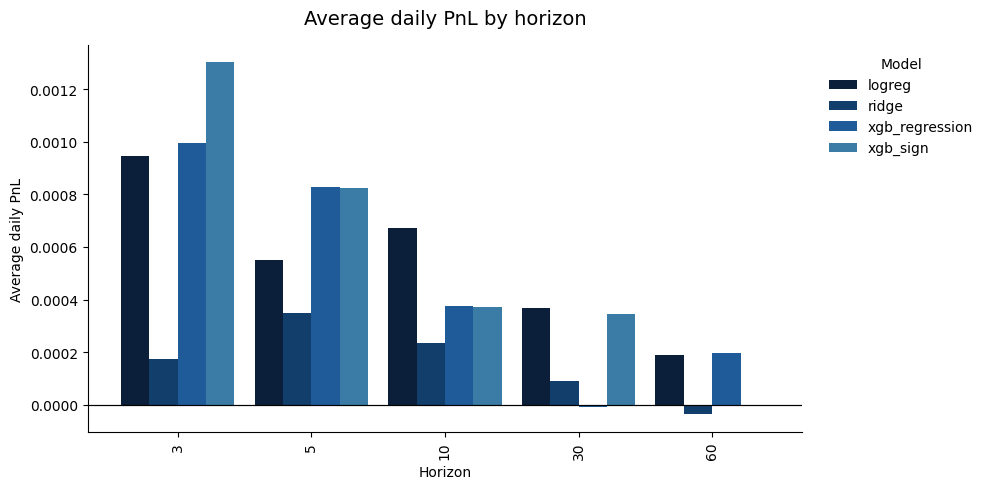

In [24]:
colors = ["#0B1F3A", "#123E6B", "#1F5A99", "#3A7CA5"]

pivot = (
    res
    .groupby(["h", "model"])["avg_pnl"]
    .mean()
    .unstack()
)

ax = pivot.plot(
    kind="bar",
    figsize=(10, 5),
    color=colors,
    width=0.85
)

ax.set_title("Average daily PnL by horizon", fontsize=14, pad=15)
ax.set_xlabel("Horizon")
ax.set_ylabel("Average daily PnL")

ax.axhline(0, color="black", lw=0.8)
ax.axhline(0, color="black", lw=0.8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Model",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

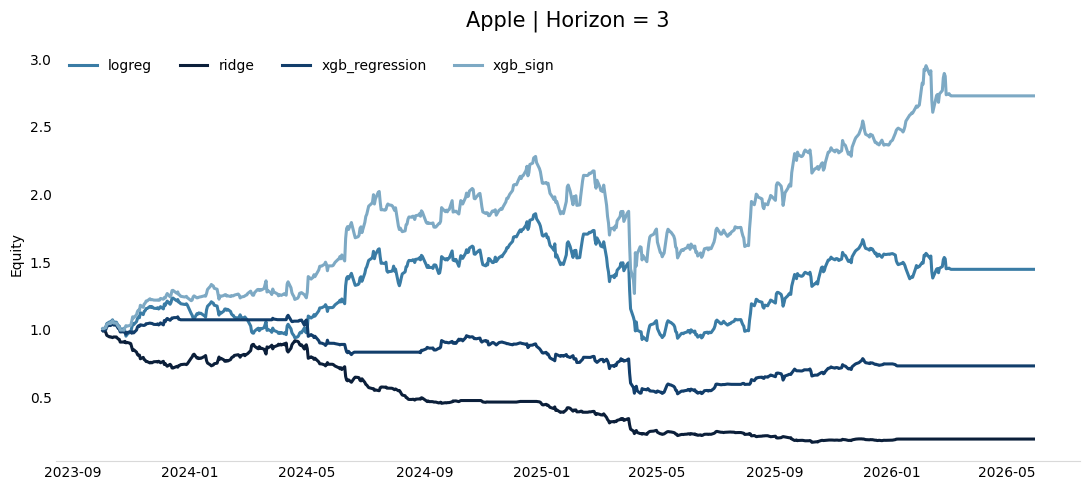

In [34]:
plt.style.use("default")

colors = {
    "ridge": "#0B1F3A",
    "xgb_regression": "#123E6B",
    "logreg": "#3A7CA5",
    "xgb_sign": "#7DA9C4",
}

fig, ax = plt.subplots(figsize=(11, 5))

for f in sorted(Path(".").glob("apple_*_3_pnl.parquet")):

    model = "_".join(
        f.stem.lower().replace("_pnl", "").split("_")[1:-1]
    )

    d = pd.read_parquet(f)

    equity = np.exp(d["ret"].cumsum())

    ax.plot(
        equity.index,
        equity.values,
        lw=2.2,
        color=colors.get(model, "#1F5A99"),
        label=model
    )

ax.set_title(
    "Apple | Horizon = 3",
    fontsize=15,
    fontweight="medium",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Equity")

ax.grid(False)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color("#D9D9D9")

ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=0)

ax.legend(
    frameon=False,
    ncol=4,
    loc="upper left"
)

plt.tight_layout()
plt.savefig('equity,png')
plt.show()

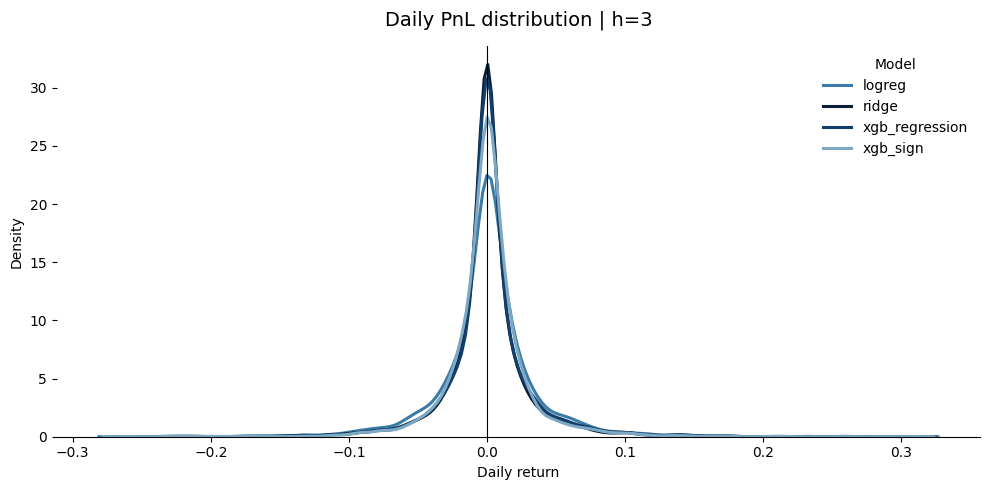

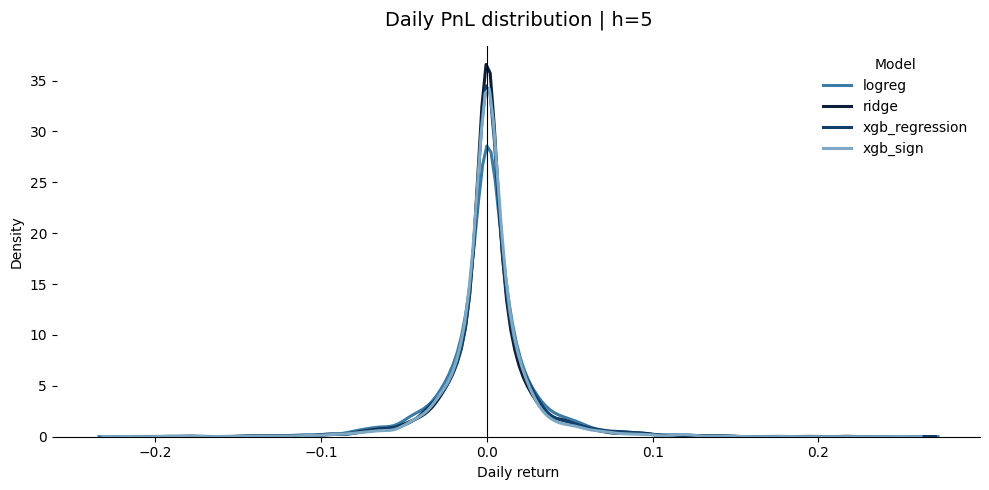

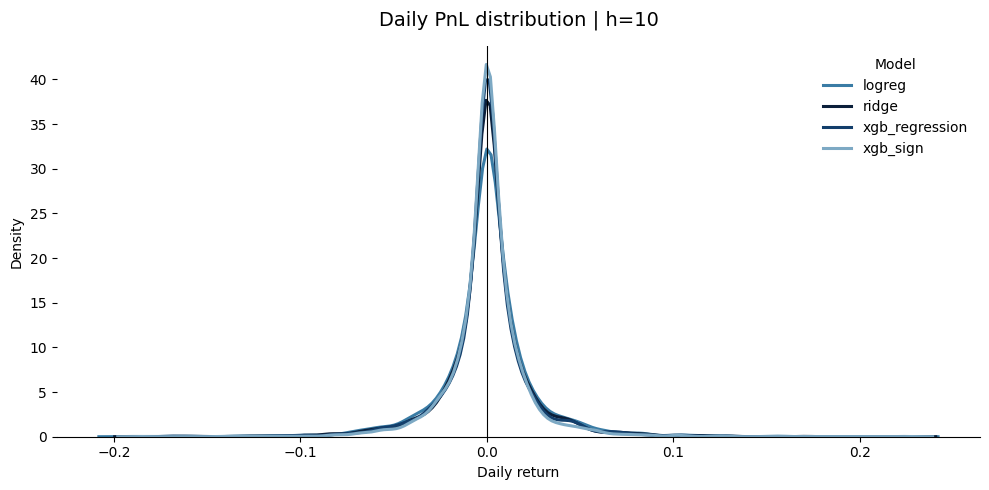

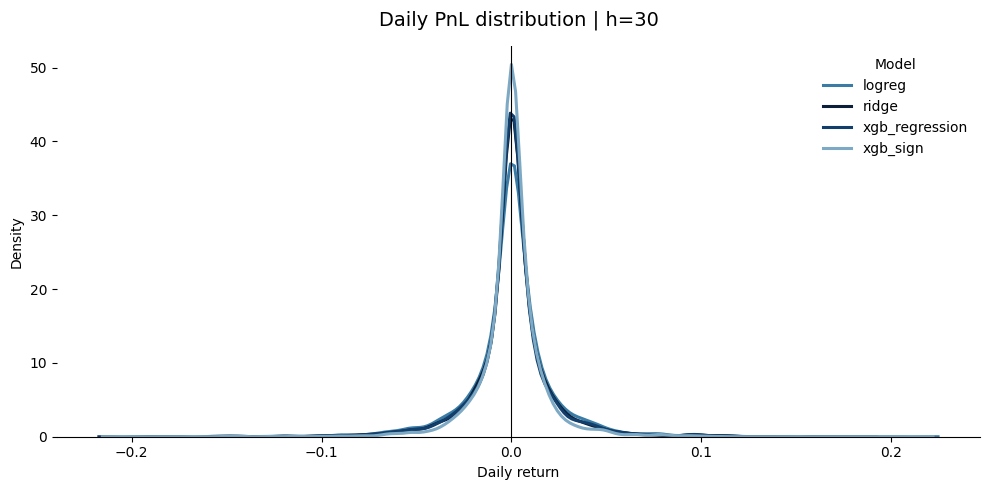

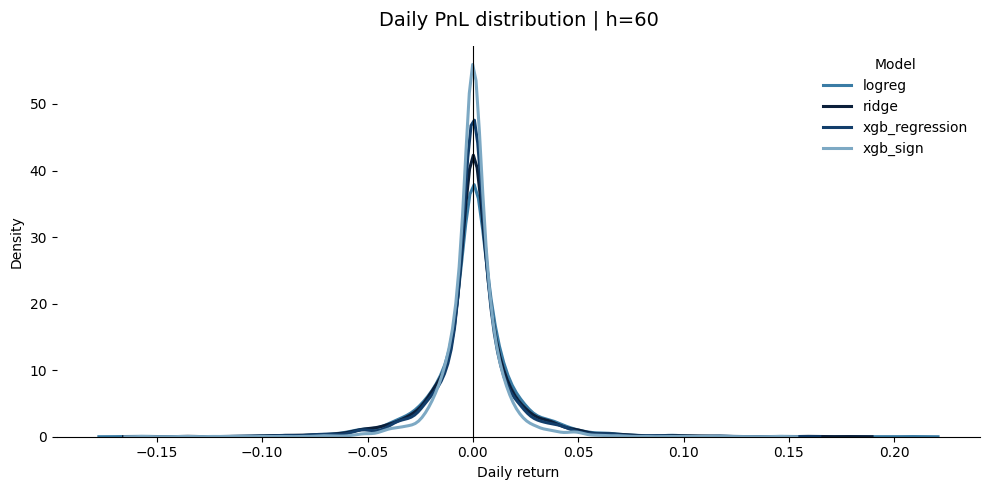

In [32]:
colors = {
    "ridge": "#0B1F3A",
    "xgb_regression": "#123E6B",
    "logreg": "#3A7CA5",
    "xgb_sign": "#7DA9C4",
}

for h in sorted(rets.h.unique()):

    fig, ax = plt.subplots(figsize=(10, 5))

    for model in sorted(rets.model.unique()):
        x = rets[(rets.h == h) & (rets.model == model)]["ret"].dropna()

        if len(x) < 10:
            continue

        sns.kdeplot(
            x=x,
            ax=ax,
            lw=2.2,
            color=colors.get(model),
            label=model,
            fill=False
        )

    ax.axvline(0, color="black", lw=.8)

    ax.set_title(f"Daily PnL distribution | h={h}", fontsize=14, pad=15)
    ax.set_xlabel("Daily return")
    ax.set_ylabel("Density")

    ax.grid(False)

    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)

    ax.legend(frameon=False, title="Model")

    plt.tight_layout()
    plt.show()

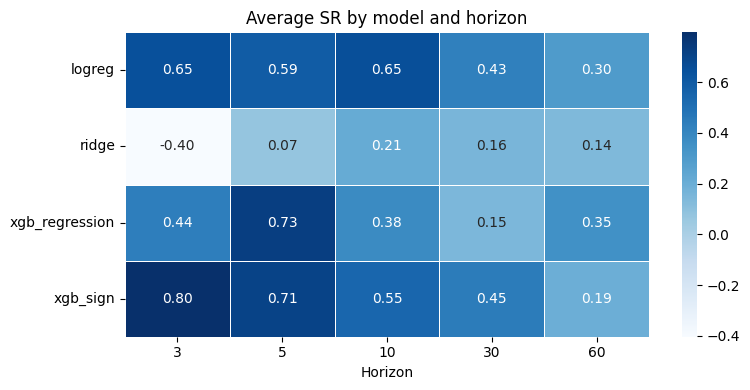

In [35]:
pivot = res.groupby(["model", "h"])["SR"].mean().unstack()

plt.figure(figsize=(8, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=.5
)
plt.title("Average SR by model and horizon")
plt.xlabel("Horizon")
plt.ylabel("")
plt.tight_layout()
plt.savefig('SR.png')
plt.show()

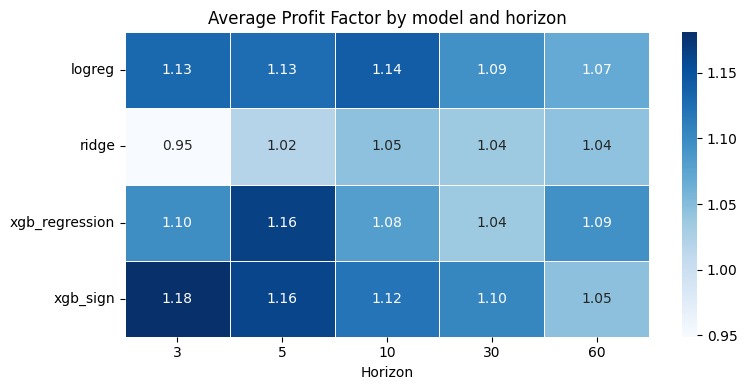

In [29]:
pivot = res.groupby(["model", "h"])["ProfitFactor"].mean().unstack()

plt.figure(figsize=(8, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=.5
)
plt.title("Average Profit Factor by model and horizon")
plt.xlabel("Horizon")
plt.ylabel("")
plt.tight_layout()
plt.show()

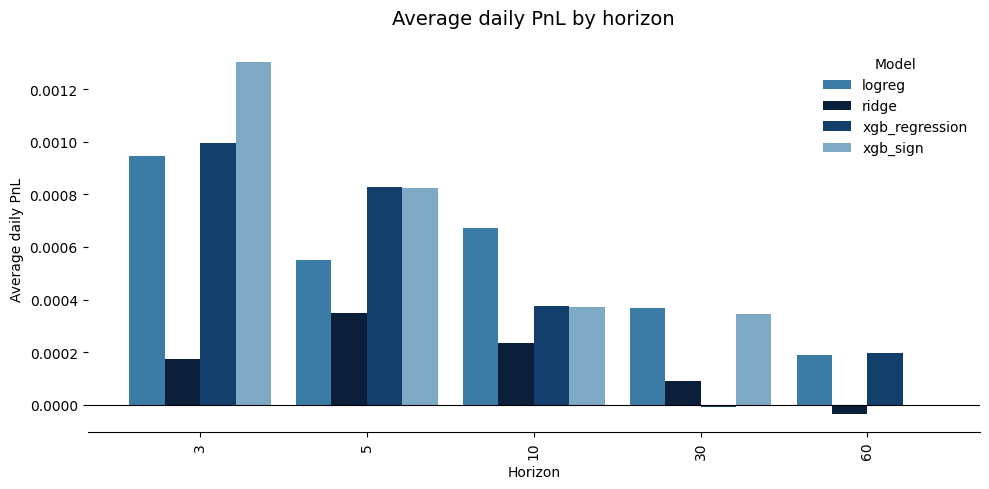

In [36]:
pivot = res.groupby(["h", "model"])["avg_pnl"].mean().unstack()

ax = pivot.plot(
    kind="bar",
    figsize=(10, 5),
    color=[colors[c] for c in pivot.columns],
    width=.85
)

ax.set_title("Average daily PnL by horizon", fontsize=14, pad=15)
ax.set_xlabel("Horizon")
ax.set_ylabel("Average daily PnL")

ax.axhline(0, color="black", lw=.8)
ax.grid(False)

for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)

ax.legend(frameon=False, title="Model")

plt.tight_layout()
plt.savefig('avvg_pnl.png')
plt.show()